In [321]:
# K mean clustring 
# it make cluster by the help of centroid
# https://docs.google.com/document/d/1hO-ggcF3qvtwsd6Vs20LvDz4MMn-TG99oxJeYnK7qRk/edit?tab=t.0

In [322]:
import pandas as pd

df = pd.DataFrame({
    'A': [2.81, 3.40, 2.63, 8.52, 9.17, 7.94, 10.17, 8.99, 2.62, 8.56,
          2.19, 3.19, 1.62, 8.52, 4.26, 8.08, 2.27, 3.52, 9.05, 9.66],
    'B': [2.81, 2.89, 2.63, 7.77, 6.43, 8.16, 7.82, 7.15, 3.43, 8.09,
          3.25, 1.47, 2.55, 9.48, 3.61, 8.30, 1.87, 4.22, 6.86, 7.02]
})

print(df)
# note here we do not divide train and test data

        A     B
0    2.81  2.81
1    3.40  2.89
2    2.63  2.63
3    8.52  7.77
4    9.17  6.43
5    7.94  8.16
6   10.17  7.82
7    8.99  7.15
8    2.62  3.43
9    8.56  8.09
10   2.19  3.25
11   3.19  1.47
12   1.62  2.55
13   8.52  9.48
14   4.26  3.61
15   8.08  8.30
16   2.27  1.87
17   3.52  4.22
18   9.05  6.86
19   9.66  7.02


In [323]:
from sklearn.preprocessing import StandardScaler

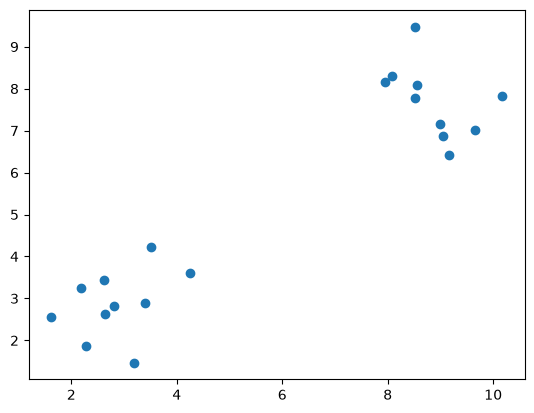

In [324]:
# ploting scatter plot 

from matplotlib import pyplot as plt
plt.scatter(df["A"],df["B"])
plt.show()




In [325]:
from sklearn.cluster import KMeans
kmeans_model = KMeans(n_clusters=2,  random_state=42)#random_state is used because initial point are randomly selected


In [326]:
labels = kmeans_model.fit_predict(df)

df["cluster"] = labels
df

,A,B,cluster
0,2.81,2.81,1
1,3.40,2.89,1
2,2.63,2.63,1
3,8.52,7.77,0
4,9.17,6.43,0
5,7.94,8.16,0
6,10.17,7.82,0
7,8.99,7.15,0
8,2.62,3.43,1
9,8.56,8.09,0


In [ ]:
# here some use elbow method
#but  silhouette score can be used for  both, KMean and  Agglomerative Clustering
#those K whose silhouette score is high are choosen


#no need to 
from sklearn.metrics import silhouette_score

scores = [ ]
k_range = range(2,11)#note always start from 2  other wise it will not work

for k in k_range :
    model = KMeans(n_clusters=k,random_state=42)
    labels = model.fit_predict(df)
    scores.append(silhouette_score(df,labels))

best_k = k_range[scores.index(max(scores))]

print(scores) #heighest score
print(best_k)


[0.8162968487372693, 0.5397609193873503, 0.3952171507381871, 0.41317793271176695, 0.3938411991210084, 0.35929845891803724, 0.2681665894198291, 0.3121985374087788, 0.305458229496109]
2


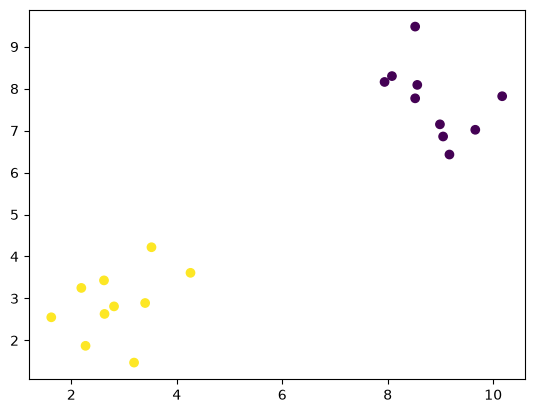

In [328]:
#lets plot
plt.scatter(df["A"],df["B"],c=df["cluster"])